# 🏭 Bài 3B: Ứng dụng thực tế Computer Vision
**Môn học**: E1402 - Digital and Computer Vision

**Thời gian**: ~45 phút | **Yêu cầu**: Đã hoàn thành Bài 1-3

---
## 🎯 Mục tiêu
Áp dụng tất cả kỹ thuật đã học vào **3 bài toán thực tế**:
1. 🔢 Đếm & phân loại vật thể theo hình dạng
2. 📄 Quét tài liệu (Document Scanner)
3. 🎨 Phát hiện & thay đổi màu vật thể

> 💡 Mỗi ứng dụng kết hợp NHIỀU kỹ thuật từ các bài trước

## ⚙️ Cài đặt

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen, Request
try:
    from google.colab import files
    COLAB = True
except ImportError:
    COLAB = False

def tai_anh(url):
    req = Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    resp = urlopen(req)
    arr = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(arr, cv2.IMREAD_COLOR)

def hien_thi(ds_anh, ds_ten, figsize=(16, 5)):
    fig, axes = plt.subplots(1, len(ds_anh), figsize=figsize)
    if len(ds_anh) == 1: axes = [axes]
    for ax, anh, ten in zip(axes, ds_anh, ds_ten):
        if len(anh.shape) == 2: ax.imshow(anh, cmap='gray')
        else: ax.imshow(cv2.cvtColor(anh, cv2.COLOR_BGR2RGB))
        ax.set_title(ten, fontsize=12, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print('✅ Sẵn sàng!')

✅ Sẵn sàng!


---
## 🔢 Ứng dụng 1: Đếm & Phân loại hình dạng

### Bài toán
Trong sản xuất, kiểm tra chất lượng yêu cầu **đếm** và **phân loại** sản phẩm tự động.

### Kỹ thuật sử dụng
```
Ảnh → Xám → Ngưỡng hóa → Contours → Phân tích hình dạng
                                         ↓
                              approxPolyDP → Số cạnh
                              3 cạnh = Tam giác
                              4 cạnh = Tứ giác
                              > 6 cạnh = Tròn
```

**Thuật toán**: `cv2.approxPolyDP()` xấp xỉ contour thành đa giác đơn giản → đếm số đỉnh = số cạnh.

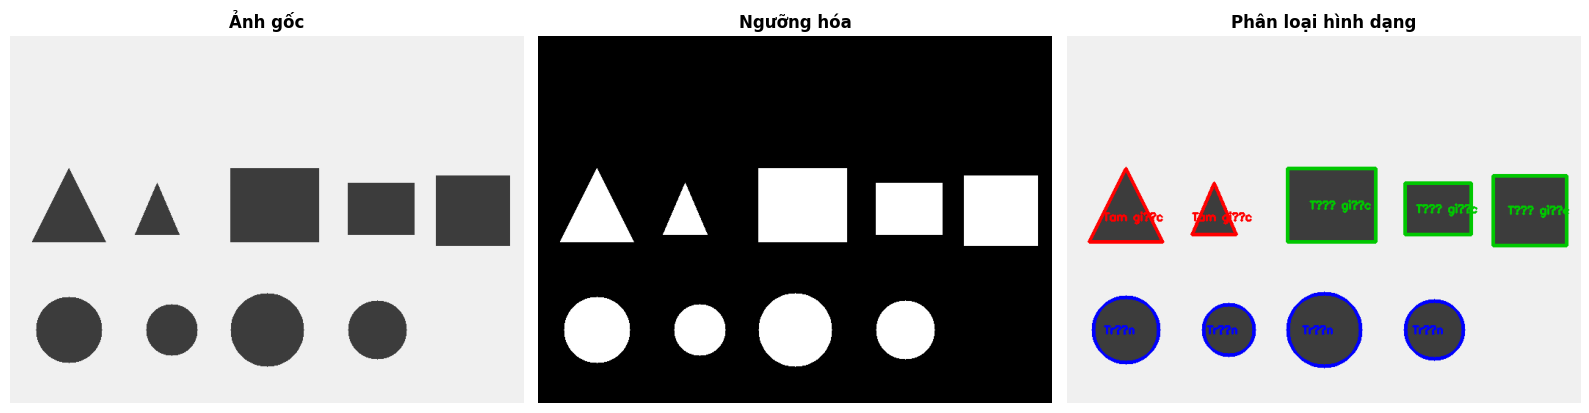

📊 Kết quả phân loại:
  Tam giác: 2
  Tứ giác: 3
  Tròn: 4
  TỔNG: 9 vật thể

✏️ THỬ: Thay epsilon = 0.01 (chính xác hơn) hoặc 0.08 (đơn giản hơn)


In [2]:
# Tạo ảnh chứa các hình dạng khác nhau
canvas = np.ones((500, 700, 3), dtype=np.uint8) * 240  # Nền sáng

# Vẽ tam giác
pts1 = np.array([[80, 180], [30, 280], [130, 280]])
cv2.fillPoly(canvas, [pts1], (60, 60, 60))
pts2 = np.array([[200, 200], [170, 270], [230, 270]])
cv2.fillPoly(canvas, [pts2], (60, 60, 60))

# Vẽ hình chữ nhật
cv2.rectangle(canvas, (300, 180), (420, 280), (60, 60, 60), -1)
cv2.rectangle(canvas, (460, 200), (550, 270), (60, 60, 60), -1)
cv2.rectangle(canvas, (580, 190), (680, 285), (60, 60, 60), -1)

# Vẽ hình tròn
cv2.circle(canvas, (80, 400), 45, (60, 60, 60), -1)
cv2.circle(canvas, (220, 400), 35, (60, 60, 60), -1)
cv2.circle(canvas, (350, 400), 50, (60, 60, 60), -1)
cv2.circle(canvas, (500, 400), 40, (60, 60, 60), -1)

# === PHÁT HIỆN VÀ PHÂN LOẠI ===
xam = cv2.cvtColor(canvas, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(xam, 128, 255, cv2.THRESH_BINARY_INV)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Phân loại từng contour
ket_qua = canvas.copy()
dem = {'Tam giác': 0, 'Tứ giác': 0, 'Tròn': 0, 'Khác': 0}
mau = {'Tam giác': (0,0,255), 'Tứ giác': (0,200,0), 'Tròn': (255,0,0), 'Khác': (128,128,128)}

for cnt in contours:
    if cv2.contourArea(cnt) < 300:  # Bỏ nhiễu nhỏ
        continue
    # Xấp xỉ đa giác
    epsilon = 0.03 * cv2.arcLength(cnt, True)  # Sai số cho phép 3%
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    so_canh = len(approx)

    # Phân loại theo số cạnh
    if so_canh == 3:
        loai = 'Tam giác'
    elif so_canh == 4:
        loai = 'Tứ giác'
    elif so_canh > 6:
        loai = 'Tròn'
    else:
        loai = 'Khác'

    dem[loai] += 1
    cv2.drawContours(ket_qua, [cnt], -1, mau[loai], 3)

    # Ghi nhãn
    M = cv2.moments(cnt)
    if M['m00'] > 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        cv2.putText(ket_qua, loai, (cx-30, cy+5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, mau[loai], 2)

hien_thi([canvas, thresh, ket_qua],
         ['Ảnh gốc', 'Ngưỡng hóa', 'Phân loại hình dạng'])

print('📊 Kết quả phân loại:')
for loai, so in dem.items():
    if so > 0:
        print(f'  {loai}: {so}')
print(f'  TỔNG: {sum(dem.values())} vật thể')
print('\n✏️ THỬ: Thay epsilon = 0.01 (chính xác hơn) hoặc 0.08 (đơn giản hơn)')

---
## 📄 Ứng dụng 2: Quét tài liệu (Document Scanner)

### Bài toán
Chụp ảnh tài liệu bằng điện thoại → tự động cắt, xoay thẳng, tăng tương phản.

**Ứng dụng**: CamScanner, Adobe Scan, Google Drive Scan

### Quy trình 5 bước
```
1. Ảnh gốc (nghiêng)
2. → Canny phát hiện cạnh
3. → findContours tìm viền giấy (contour lớn nhất, 4 cạnh)
4. → getPerspectiveTransform "kéo thẳng" 4 góc
5. → Adaptive Threshold tạo ảnh scan đen trắng sạch
```

**Kỹ thuật chính**: `cv2.getPerspectiveTransform()` + `cv2.warpPerspective()` 
→ Biến đổi phối cảnh: từ hình thang → hình chữ nhật

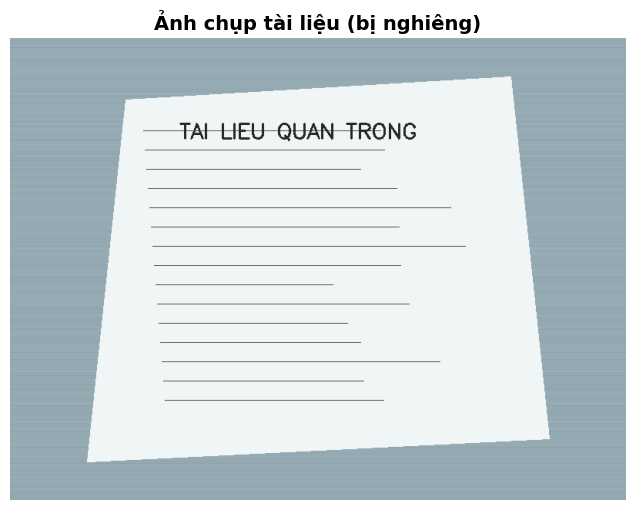

In [3]:
# Tạo ảnh giả lập: tài liệu bị nghiêng trên nền bàn
nen = np.ones((600, 800, 3), dtype=np.uint8) * np.array([180, 170, 150], dtype=np.uint8)
# Thêm texture cho nền (giả lập bàn gỗ)
for i in range(0, 600, 3):
    nen[i:i+1, :] = nen[i:i+1, :] * np.random.uniform(0.95, 1.05)
nen = np.clip(nen, 0, 255).astype(np.uint8)

# Vẽ trang giấy (hình tứ giác - nghiêng)
pts_giay = np.array([[150, 80], [650, 50], [700, 520], [100, 550]])
cv2.fillPoly(nen, [pts_giay], (245, 245, 240))  # Giấy trắng
# Thêm text giả trên giấy
for y in range(120, 490, 25):
    x1 = int(150 + (y - 80) * 0.08)
    w = np.random.randint(250, 450)
    cv2.line(nen, (x1+20, y), (x1+w, y), (80, 80, 80), 1)
# Tiêu đề
cv2.putText(nen, 'TAI LIEU QUAN TRONG', (220, 130),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (40, 40, 40), 2)

anh_scan = nen.copy()
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(anh_scan, cv2.COLOR_BGR2RGB))
plt.title('Ảnh chụp tài liệu (bị nghiêng)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

✅ Tìm thấy viền tài liệu! 4 góc: [[650, 50], [150, 80], [100, 550], [700, 520]]


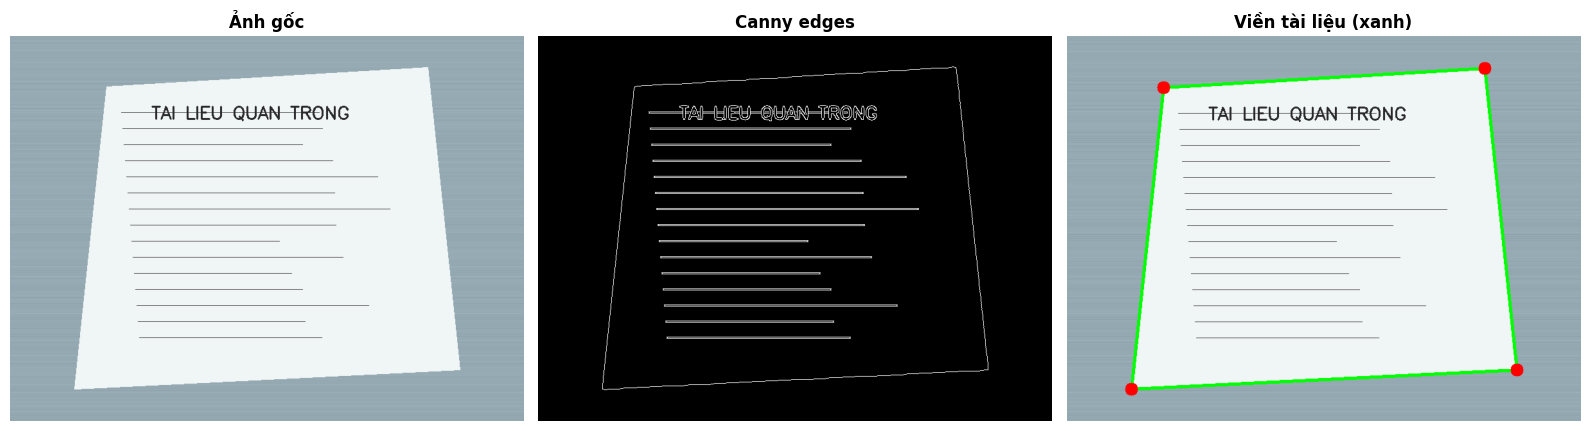

In [4]:
# === BƯỚC 1: Phát hiện cạnh ===
xam = cv2.cvtColor(anh_scan, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(xam, (5, 5), 0)
canh = cv2.Canny(blur, 50, 150)

# === BƯỚC 2: Tìm contour lớn nhất có 4 đỉnh ===
contours, _ = cv2.findContours(canh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)  # Sắp xếp theo diện tích

vien_giay = None
for cnt in contours:
    epsilon = 0.02 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    if len(approx) == 4 and cv2.contourArea(cnt) > 10000:  # 4 đỉnh + đủ lớn
        vien_giay = approx
        break

anh_vien = anh_scan.copy()
if vien_giay is not None:
    cv2.drawContours(anh_vien, [vien_giay], -1, (0, 255, 0), 3)
    for pt in vien_giay:
        cv2.circle(anh_vien, tuple(pt[0]), 10, (0, 0, 255), -1)
    print(f'✅ Tìm thấy viền tài liệu! 4 góc: {vien_giay.reshape(4, 2).tolist()}')
else:
    print('❌ Không tìm thấy viền 4 cạnh')

hien_thi([anh_scan, canh, anh_vien],
         ['Ảnh gốc', 'Canny edges', 'Viền tài liệu (xanh)'])

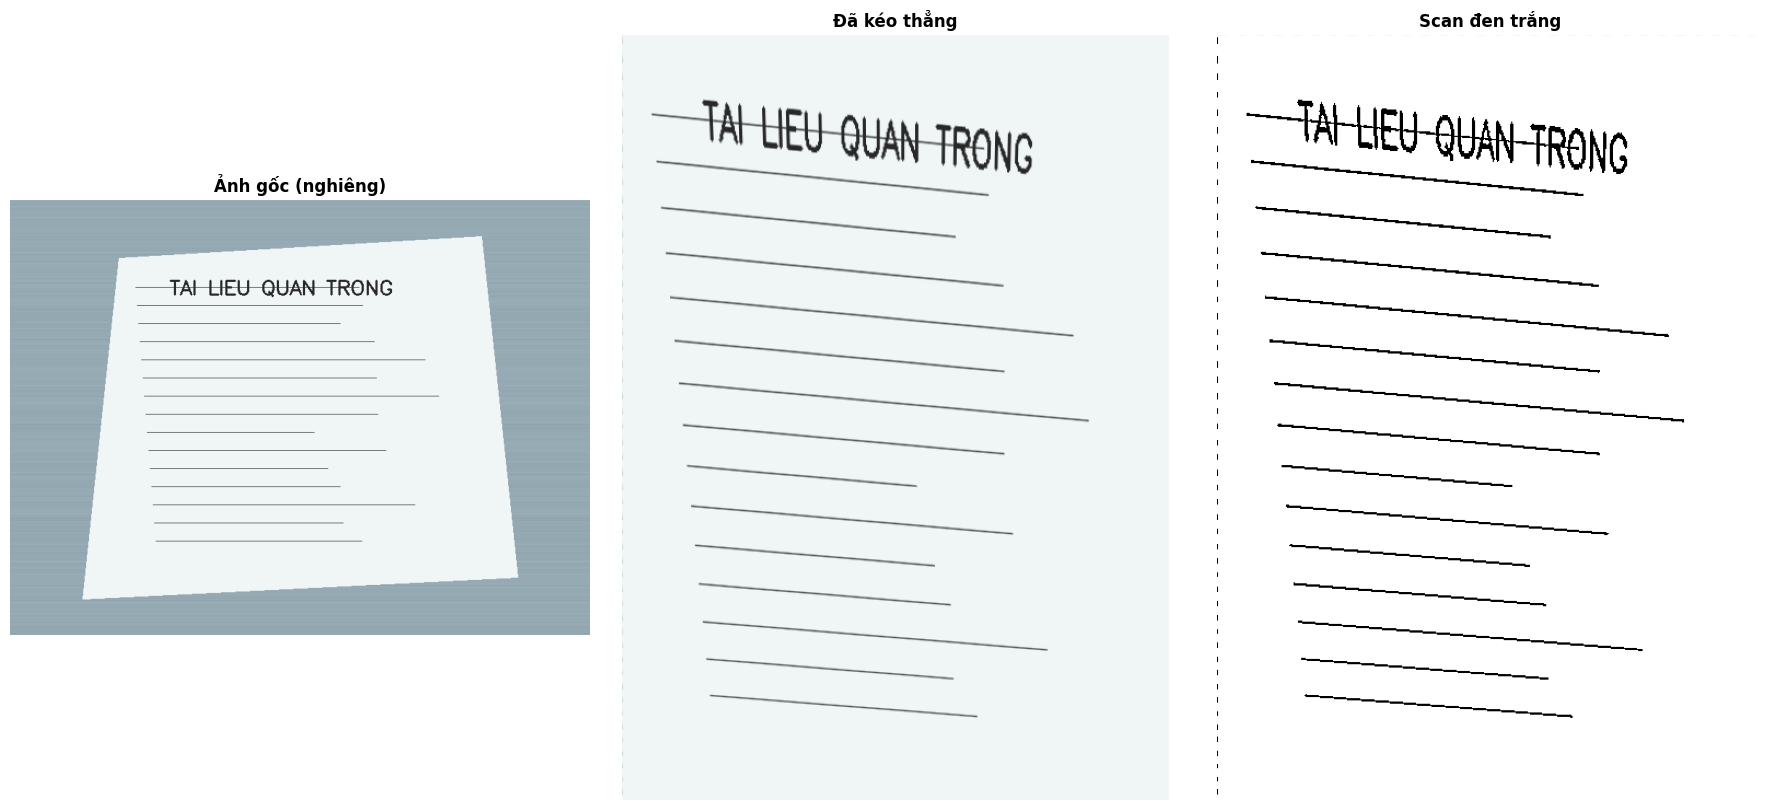

✅ Quét tài liệu hoàn tất!
📌 Quy trình: Canny → Contour 4 đỉnh → Perspective Transform → Threshold


In [5]:
# === BƯỚC 3: Biến đổi phối cảnh (Perspective Transform) ===
if vien_giay is not None:
    # Sắp xếp 4 góc: trái-trên, phải-trên, phải-dưới, trái-dưới
    pts = vien_giay.reshape(4, 2).astype(np.float32)
    # Sắp xếp theo tọa độ
    s = pts.sum(axis=1)
    d = np.diff(pts, axis=1).flatten()
    goc_sap_xep = np.array([
        pts[np.argmin(s)],     # Trái-trên (x+y nhỏ nhất)
        pts[np.argmin(d)],     # Phải-trên (x-y nhỏ nhất)
        pts[np.argmax(s)],     # Phải-dưới (x+y lớn nhất)
        pts[np.argmax(d)],     # Trái-dưới (x-y lớn nhất)
    ], dtype=np.float32)

    # Kích thước đầu ra (A4 tỷ lệ)
    rong_moi, cao_moi = 500, 700
    dich = np.array([
        [0, 0], [rong_moi, 0],
        [rong_moi, cao_moi], [0, cao_moi]
    ], dtype=np.float32)

    # Ma trận biến đổi phối cảnh
    M = cv2.getPerspectiveTransform(goc_sap_xep, dich)
    scan_thang = cv2.warpPerspective(anh_scan, M, (rong_moi, cao_moi))

    # === BƯỚC 4: Tăng cường (scan đen trắng sạch) ===
    scan_xam = cv2.cvtColor(scan_thang, cv2.COLOR_BGR2GRAY)
    scan_sach = cv2.adaptiveThreshold(
        scan_xam, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 5
    )

    hien_thi([anh_scan, scan_thang, scan_sach],
             ['Ảnh gốc (nghiêng)', 'Đã kéo thẳng', 'Scan đen trắng'],
             figsize=(18, 8))
    print('✅ Quét tài liệu hoàn tất!')
    print('📌 Quy trình: Canny → Contour 4 đỉnh → Perspective Transform → Threshold')

---
## 🎨 Ứng dụng 3: Phát hiện & Thay đổi màu vật thể

### Bài toán
**Thay đổi màu sắc** của vật thể cụ thể trong ảnh - ứng dụng trong:
- 🏠 Xem trước màu sơn nhà
- 👗 Thử màu quần áo online
- 🚗 Đổi màu xe ô tô

### Kỹ thuật
```
1. HSV Masking → tìm vùng có màu cần thay
2. Tạo mask → xác định chính xác vùng đó
3. Thay kênh H (Hue) → đổi sang màu mới
4. Ghép lại → ảnh với màu mới
```

/var/folders/gn/__q44dqx4g94_zn16nx2720w0000gn/T/ipykernel_81439/4283757759.py:54: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/phongdang/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


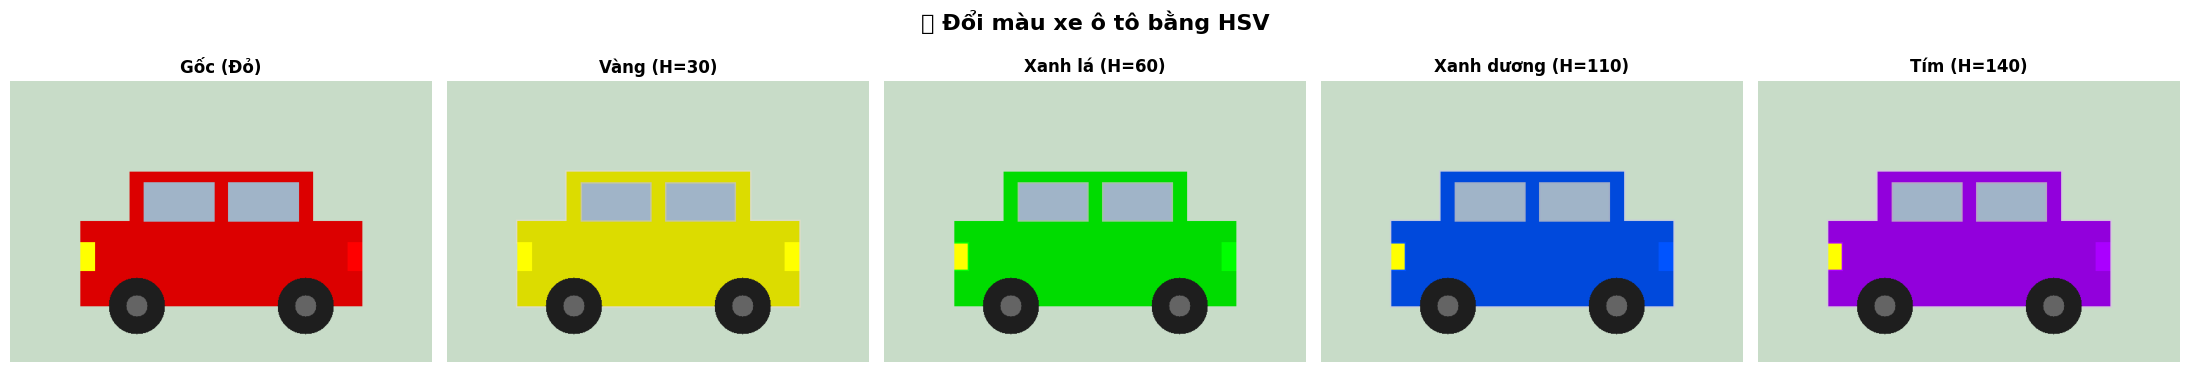

📌 Chỉ cần thay kênh H (Hue) → đổi màu mà giữ nguyên độ sáng & chi tiết!
✏️ THỬ: Đổi mau_moi_H = 0 (đỏ đậm), 90 (cyan), 160 (hồng)


In [6]:
# Tạo ảnh xe ô tô đơn giản (màu đỏ)
oto = np.ones((400, 600, 3), dtype=np.uint8) * np.array([200, 220, 200], dtype=np.uint8)

# Thân xe (đỏ)
cv2.rectangle(oto, (100, 200), (500, 320), (0, 0, 220), -1)
cv2.rectangle(oto, (170, 130), (430, 210), (0, 0, 220), -1)
# Cửa kính
cv2.rectangle(oto, (190, 145), (290, 200), (200, 180, 160), -1)
cv2.rectangle(oto, (310, 145), (410, 200), (200, 180, 160), -1)
# Bánh xe
cv2.circle(oto, (180, 320), 40, (30, 30, 30), -1)
cv2.circle(oto, (180, 320), 15, (100, 100, 100), -1)
cv2.circle(oto, (420, 320), 40, (30, 30, 30), -1)
cv2.circle(oto, (420, 320), 15, (100, 100, 100), -1)
# Đèn
cv2.rectangle(oto, (100, 230), (120, 270), (0, 255, 255), -1)
cv2.rectangle(oto, (480, 230), (500, 270), (0, 0, 255), -1)

# === ĐỔI MÀU XE ===
# Bước 1: Tìm vùng màu đỏ (thân xe)
hsv = cv2.cvtColor(oto, cv2.COLOR_BGR2HSV)
mask_do = cv2.inRange(hsv, np.array([0, 50, 50]), np.array([10, 255, 255]))
mask_do = cv2.dilate(mask_do, np.ones((5, 5), np.uint8))  # Mở rộng một chút

# ===== CHỌN MÀU MỚI =====
mau_moi_H = 110  # 0=Đỏ, 30=Vàng, 60=Xanh lá, 90=Cyan, 110=Xanh dương, 140=Tím
# ========================

# Bước 2: Thay kênh H (Hue) = thay loại màu
hsv_moi = hsv.copy()
hsv_moi[mask_do > 0, 0] = mau_moi_H  # Chỉ đổi H ở vùng mask

# Bước 3: Chuyển lại BGR
oto_moi = cv2.cvtColor(hsv_moi, cv2.COLOR_HSV2BGR)

# Thử nhiều màu
ds_mau = [30, 60, 110, 140]  # Vàng, Xanh lá, Xanh dương, Tím
ten_mau = ['Vàng', 'Xanh lá', 'Xanh dương', 'Tím']
ds_xe = []
for h in ds_mau:
    tmp = hsv.copy()
    tmp[mask_do > 0, 0] = h
    ds_xe.append(cv2.cvtColor(tmp, cv2.COLOR_HSV2BGR))

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
axes[0].imshow(cv2.cvtColor(oto, cv2.COLOR_BGR2RGB))
axes[0].set_title('Gốc (Đỏ)', fontsize=12, fontweight='bold')
axes[0].axis('off')
for i, (xe, ten) in enumerate(zip(ds_xe, ten_mau)):
    axes[i+1].imshow(cv2.cvtColor(xe, cv2.COLOR_BGR2RGB))
    axes[i+1].set_title(f'{ten} (H={ds_mau[i]})', fontsize=12, fontweight='bold')
    axes[i+1].axis('off')
plt.suptitle('🎨 Đổi màu xe ô tô bằng HSV', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 Chỉ cần thay kênh H (Hue) → đổi màu mà giữ nguyên độ sáng & chi tiết!')
print('✏️ THỬ: Đổi mau_moi_H = 0 (đỏ đậm), 90 (cyan), 160 (hồng)')

---
## 🏆 Bài tập thử thách

### Thử thách 1: Đếm hình dạng trên ảnh upload
Upload ảnh có các hình dạng → chương trình tự phân loại

In [7]:
# Upload hoặc nhập đường dẫn ảnh
if COLAB:
    print('📤 Upload ảnh có các hình dạng...')
    uploaded = files.upload()
    for ten, dl in uploaded.items():
        arr = np.frombuffer(dl, dtype=np.uint8)
        anh_thu = cv2.imdecode(arr, cv2.IMREAD_COLOR)
        break
else:
    duong_dan = input('📁 Nhập đường dẫn ảnh: ')
    anh_thu = cv2.imread(duong_dan)

if anh_thu is not None:
    if max(anh_thu.shape[:2]) > 600:
        r = 600 / max(anh_thu.shape[:2])
        anh_thu = cv2.resize(anh_thu, None, fx=r, fy=r)

    xam = cv2.cvtColor(anh_thu, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(xam, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    kq = anh_thu.copy()
    dem = {'Tam giác':0, 'Tứ giác':0, 'Tròn':0, 'Khác':0}
    for cnt in contours:
        if cv2.contourArea(cnt) < 300: continue
        eps = 0.03 * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, eps, True)
        n = len(approx)
        loai = 'Tam giác' if n==3 else 'Tứ giác' if n==4 else 'Tròn' if n>6 else 'Khác'
        dem[loai] += 1
        c = (0,0,255) if n==3 else (0,200,0) if n==4 else (255,0,0) if n>6 else (128,128,128)
        cv2.drawContours(kq, [cnt], -1, c, 2)

    hien_thi([anh_thu, kq], ['Ảnh gốc', 'Phân loại'], figsize=(14, 5))
    for l, s in dem.items():
        if s > 0: print(f'  {l}: {s}')
else:
    print('❌ Không đọc được ảnh')

❌ Không đọc được ảnh


[ WARN:0@4.888] global loadsave.cpp:275 findDecoder imread_(''): can't open/read file: check file path/integrity


---
## 📊 Tổng kết

| Ứng dụng | Kỹ thuật chính | Bài liên quan |
|---|---|---|
| Đếm & phân loại | Contours + approxPolyDP | Bài 2 (Contours) |
| Quét tài liệu | Canny + Perspective Transform | Bài 2 (Edge) |
| Đổi màu | HSV Masking + Hue replacement | Bài 1 (HSV) + Bài 3 (Morphology) |

**📌 Computer Vision = Kết hợp nhiều kỹ thuật đơn giản → giải quyết bài toán phức tạp!**